# Notebook figures: TCR library QC & associating genetic screening results with VDJDb/literature annotation, 
#### Figure panels: 1B, 1E, S2D, 2B, S3B, 3A, 3B, 3C, S3J, 5A & B (example illustration plots)

In [ ]:
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt

from dotenv import load_dotenv
 
load_dotenv()
import os
from pathlib import Path

tcr_toolbox_path = os.getenv("tcr_toolbox_path")
import json
import os
import re
from functools import reduce
from typing import Union

import numpy as np
import pandas as pd
import pysam
import scipy as sp

from tcr_toolbox.utils.plot_utils import generate_color_dict, startfig, view_color_dict

In [ ]:
mylines = 0.75  # updated
mpl.rcParams["axes.linewidth"] = mylines  # default 1
mpl.rcParams["ytick.direction"] = "out"  # default 'in'
mpl.rcParams["xtick.direction"] = "out"  # default 'in'
mpl.rcParams["xtick.major.size"] = 3.5  # default 4
mpl.rcParams["ytick.major.size"] = 3.5  # default 4
mpl.rcParams["xtick.major.width"] = mylines  # default 0.5
mpl.rcParams["ytick.major.width"] = mylines  # default 0.5
mpl.rcParams["grid.linewidth"] = mylines / 1.5  # default 0.5
mpl.rcParams["grid.color"] = "0.8"  # default 'k'
mpl.rcParams["grid.linestyle"] = "solid"  # default ':'
mpl.rcParams["legend.frameon"] = False  # default True
mpl.rcParams["font.family"] = "Arial"  # added
mpl.rcParams["figure.dpi"] = 300
mpl.rc("savefig", dpi=300)
mpl.rcParams["pdf.fonttype"] = 42  # embed fonts as editable text in illustrator
mpl.rcParams["ps.fonttype"] = 42  # embed fonts as editable text in illustrator`

## Figure 1B

In [ ]:
sanger_df = pd.read_excel(
    "sanger-qc_tcr-platform-overview.xlsx"
)

In [4]:
sanger_df.shape[0]

82

In [ ]:
pattern = r"^[I-P]\d{1,2}$"
sanger_df.loc[:, "bottom_half"] = [True if re.fullmatch(pattern, well) else False for well in sanger_df.loc[:, "well"]]

sanger_df["Library"] = sanger_df.apply(
    lambda row: row["Library"] + "_1"
    if row["Library"] == "Stapler" and row["bottom_half"]
    else row["Library"] + "_2"
    if row["Library"] == "Stapler"
    else row["Library"],
    axis=1,
)


In [ ]:
tcr_name_map = {
    "Stapler_1": "VDJdb-10",
    "R7": "TCR-s2",
    "Neo": "TCR-s3",
    "hc_cd8": "TCR-s4",
    "treg_cd4": "TCR-s4",
    "Stapler_2": "TCR-s1",
}

n_tcr_lib_map = {
    "Stapler_1": 3693,
    "Stapler_2": 3510,
    "R7": 393 + 96 + 494,
    "Neo": 1000,
    "hc_cd8": 2293 + 599,
}


color_dict = {
    "Stapler_1": "#5C6E66",
    "Stapler_2": "darkblue",
    "R7": "#F8DEC0",
    "Neo": "#AE424B",
    "hc_cd8": "#8E9B5B",
    "treg_cd4": "#7D4E53",
}

In [ ]:
print(n_tcr_lib_map["R7"])
print(n_tcr_lib_map["hc_cd8"])

983
2892


In [9]:
sum(list(n_tcr_lib_map.values()))

12078

In [ ]:
sanger_df.loc[:, "Library"] = sanger_df.loc[:, "Library"].replace({"treg_cd4": "hc_cd8"})

In [ ]:
# print(sanger_df.loc[:, 'Library'].unique())
libraries = ["Stapler_1", "Stapler_2", "R7", "Neo", "hc_cd8"]

In [ ]:
n_well_lib_map = dict(
    zip(
        libraries,
        [sanger_df.loc[sanger_df.loc[:, "Library"] == lib, :].shape[0] for lib in libraries],
    )
)

print(n_well_lib_map)

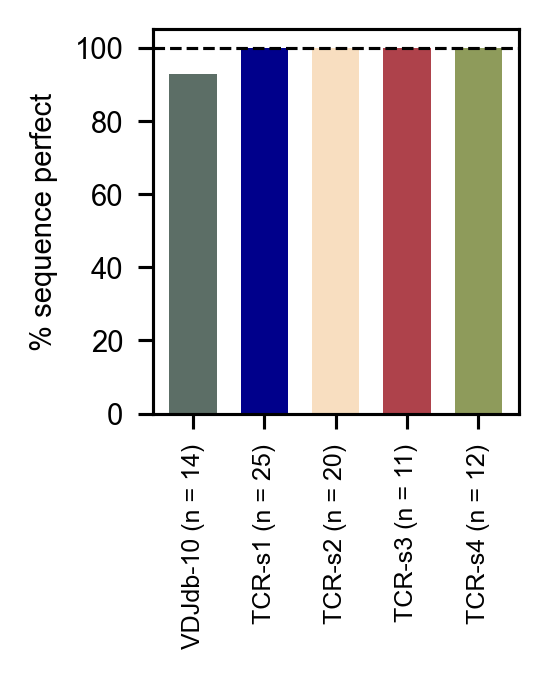

In [ ]:
bar_space = 0.35
bar_width = 0.7
num_bars = len(libraries)

w = (num_bars * bar_width) + ((num_bars - 1) * bar_space)
x_pos_list = np.arange(num_bars) * (bar_width + bar_space)
ax, fig, gs = startfig(w, 6)

for x, lib in zip(x_pos_list, libraries):
    success_percent = (
        sanger_df.loc[sanger_df.loc[:, "Library"] == lib, "Success"].sum()
        / sanger_df.loc[sanger_df.loc[:, "Library"] == lib, "Success"].shape[0]
        * 100
    )
    ax.bar(x, success_percent, width=bar_width, color=color_dict[lib])

ax.axhline(100, linestyle="--", color="black", linewidth=0.75)
ax.set_xticks(x_pos_list)
ax.set_xticklabels(
    [tcr_name_map[lib] + " (n = " + str(n_well_lib_map[lib]) + ")" for lib in libraries],
    fontsize=6,
    rotation=90,
)
ax.tick_params(axis="y", labelsize=7)
ax.set_ylabel("% sequence perfect", fontsize=7)
# ax.set_title('Validation of bulk well TCR assembly product', fontsize = 8)
fig.tight_layout()
fig.savefig(
    "figure_2b_mini_sanger_succes_bar.pdf"
)

## Figure 1E

In [ ]:
counts_df = pd.read_csv(
    "concatenated_barcode02_vdjdb_technical_duplicate_2_filtered_umi_count.csv"
)

In [ ]:
counts_df.shape[0] / n_tcr_lib_map["Stapler_1"]

0.9615488762523694

In [102]:
counts_df.shape[0]

3551

8.906664409770052
1.3585858908092325
6.115384615384615


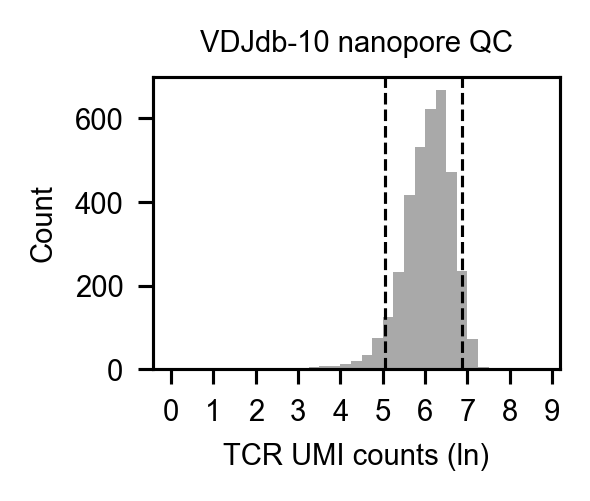

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

print(counts_df.loc[:, "log_transformed_count"].max())
ax.hist(
    counts_df.loc[:, "log_transformed_count"],
    bins=np.arange(0, 9, 0.25),
    color="darkgrey",
)

print(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95) / counts_df.loc[:, "log_transformed_count"].quantile(0.05)
)
print(counts_df.loc[:, "Count"].quantile(0.95) / counts_df.loc[:, "Count"].quantile(0.05))

ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 10, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("VDJdb-10 nanopore QC", fontsize=7)
fig.tight_layout()
fig.savefig(
    "stapler_deeper_plasmid_umi_counts_vdjdb.pdf"
)

## Figure S2D

In [ ]:
counts_df = pd.read_csv(
    "tcr_toolbox_tcr_assembly_runs/r3_2023-08-23_any_mers_full_seq_dataset_vdjdb_only/v6/sequencing_quality_analysis/outs/concatenated_barcode01_vdjdb_technical_duplicate_1/concatenated_barcode01_vdjdb_technical_duplicate_1_filtered_umi_count.csv"
)

1.396868161362194
6.859375


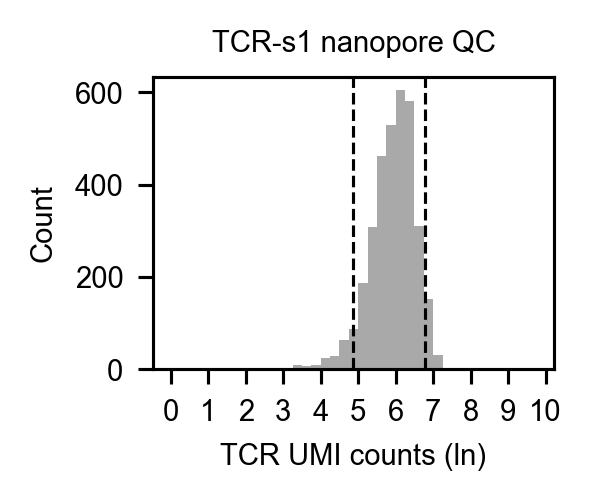

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

ax.hist(
    counts_df.loc[:, "log_transformed_count"],
    bins=np.arange(0, 10, 0.25),
    color="darkgrey",
)

print(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95) / counts_df.loc[:, "log_transformed_count"].quantile(0.05)
)
print(counts_df.loc[:, "Count"].quantile(0.95) / counts_df.loc[:, "Count"].quantile(0.05))

ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 11, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("TCR-s1 nanopore QC", fontsize=7)
fig.tight_layout()
fig.savefig(
    "stapler_deeper_plasmid_umi_counts_duplicate_1_tcr_s1.pdf"
)

In [ ]:
counts_df.shape[0] / n_tcr_lib_map["Stapler_2"] * 100

97.03703703703704

In [107]:
counts_df.shape[0]

3406

In [ ]:
counts_df_a = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r7_ywe_t500_nsclc57_no3lam397_1st_ylq_gen/v1/sequencing_quality_analysis/outs/concatenated_barcode14_NSCLC57/concatenated_barcode14_NSCLC57_filtered_umi_count.csv",
    index_col=0,
)

counts_df_b = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r7_ywe_t500_nsclc57_no3lam397_1st_ylq_gen/v1/sequencing_quality_analysis/outs/concatenated_barcode15_N03LAM397/concatenated_barcode15_N03LAM397_filtered_umi_count.csv",
    index_col=0,
)

counts_df_c = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r7_ywe_t500_nsclc57_no3lam397_1st_ylq_gen/v1/sequencing_quality_analysis/outs/concatenated_barcode16_YWE/concatenated_barcode16_YWE_filtered_umi_count.csv",
    index_col=0,
)

In [78]:
count_df_list = [counts_df_a, counts_df_b, counts_df_c]
merged_count_df = pd.concat([count_df for count_df in count_df_list])

1.3148733028218593
5.027251184834122


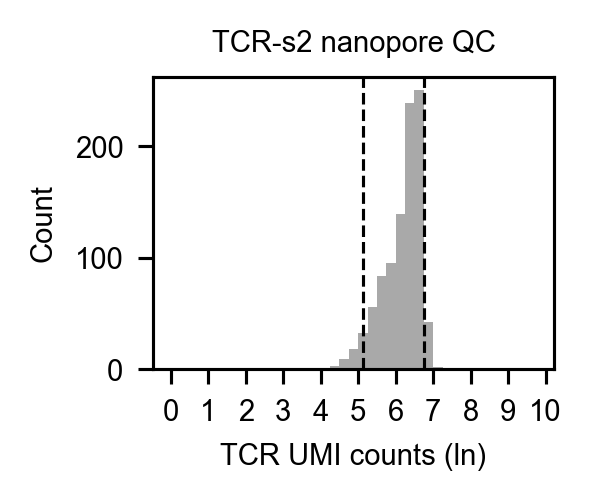

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

ax.hist(
    merged_count_df.loc[:, "log_transformed_count"],
    bins=np.arange(0, 10, 0.25),
    color="darkgrey",
)

print(
    merged_count_df.loc[:, "log_transformed_count"].quantile(0.95)
    / merged_count_df.loc[:, "log_transformed_count"].quantile(0.05)
)
print(merged_count_df.loc[:, "Count"].quantile(0.95) / merged_count_df.loc[:, "Count"].quantile(0.05))

ax.axvline(
    merged_count_df.loc[:, "log_transformed_count"].quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    merged_count_df.loc[:, "log_transformed_count"].quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 11, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("TCR-s2 nanopore QC", fontsize=7)
fig.tight_layout()
fig.savefig(
    "r7_tcr_s2.pdf"
)

In [ ]:
# Sensitivity
merged_count_df.shape[0] / n_tcr_lib_map["R7"] * 100

98.57578840284842

In [112]:
merged_count_df.shape[0]

969

In [ ]:
n_tcr_lib_map["R7"]

983

In [ ]:
# Precision
np.average([0.7262521796026872, 0.6421096364167171, 0.6823239050380004], weights=[393, 96, 494]) * 100

69.5958942796168

In [ ]:
counts_df = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r5_neo_MOF_MEL7_top1000/v1/sequencing_quality_analysis/outs/concatenated_barcode13_neo_MOF_MEL7/concatenated_barcode13_neo_MOF_MEL7_filtered_umi_count.csv"
)

In [ ]:
print(counts_df.shape[0])
print(counts_df.shape[0] / n_tcr_lib_map["Neo"])

968
0.968


6.481577129276431
1.1727886958051343
2.524682651622003


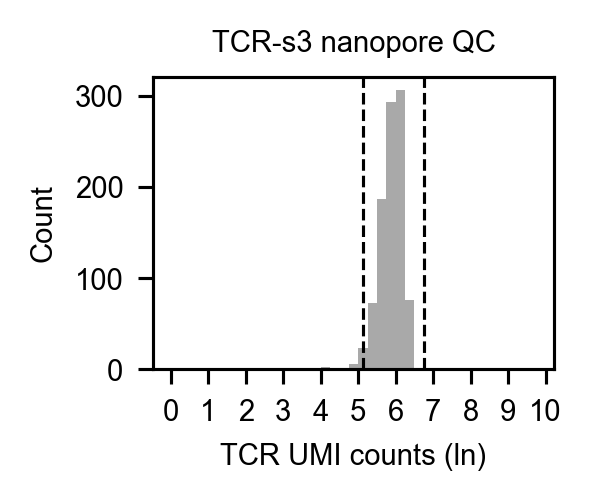

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

print(counts_df.loc[:, "log_transformed_count"].max())
ax.hist(
    counts_df.loc[:, "log_transformed_count"],
    bins=np.arange(0, 10, 0.25),
    color="darkgrey",
)

print(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95) / counts_df.loc[:, "log_transformed_count"].quantile(0.05)
)
print(counts_df.loc[:, "Count"].quantile(0.95) / counts_df.loc[:, "Count"].quantile(0.05))

ax.axvline(
    merged_count_df.loc[:, "log_transformed_count"].quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    merged_count_df.loc[:, "log_transformed_count"].quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 11, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("TCR-s3 nanopore QC", fontsize=7)
fig.tight_layout()
fig.savefig(
    "neo_top_1000_tcr_s3_plasmid_umi_counts.pdf"
)

In [ ]:
counts_df = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r2_hc_cd4_tcr_assembly_run/v2/sequencing_quality_analysis/outs/concatenated_barcode24_HC/concatenated_barcode24_HC_filtered_umi_count.csv"
)

In [ ]:
print(counts_df.shape[0])
print(counts_df.shape[0] / n_tcr_lib_map["hc_cd8"] * 100)

2811
97.19917012448133


In [ ]:
n_tcr_lib_map["hc_cd8"]

2892

9.555630757048275
1.2434621247266495
4.6


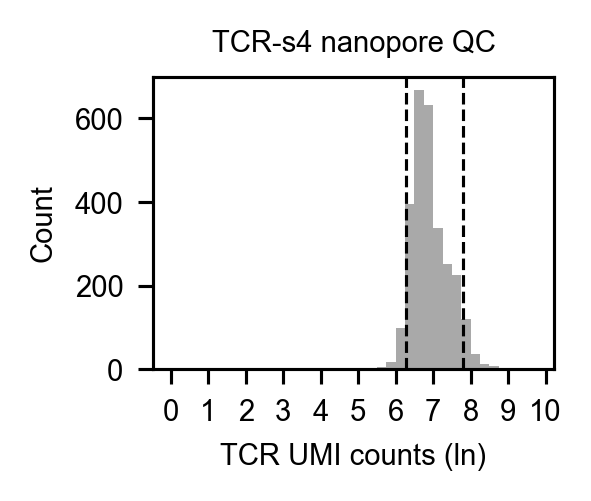

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

print(counts_df.loc[:, "log_transformed_count"].max())
ax.hist(
    counts_df.loc[:, "log_transformed_count"],
    bins=np.arange(0, 10, 0.25),
    color="darkgrey",
)

print(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95) / counts_df.loc[:, "log_transformed_count"].quantile(0.05)
)
print(counts_df.loc[:, "Count"].quantile(0.95) / counts_df.loc[:, "Count"].quantile(0.05))

ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    counts_df.loc[:, "log_transformed_count"].quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 11, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("TCR-s4 nanopore QC", fontsize=7)
fig.tight_layout()
fig.savefig(
    "hc_treg_tcr_s4_umi_counts_hist.pdf"
)

In [ ]:
np.average(
    [79.0, 76.7, 69.6, 63.8, 70.2],
    weights=[
        n_tcr_lib_map["Stapler_1"],
        n_tcr_lib_map["Stapler_2"],
        n_tcr_lib_map["R7"],
        n_tcr_lib_map["Neo"],
        n_tcr_lib_map["hc_cd8"],
    ],
)

74.20096042391125

In [ ]:
x = np.array([79.0, 76.7, 69.6, 63.8, 70.2])
w = np.array(
    [
        n_tcr_lib_map["Stapler_1"],
        n_tcr_lib_map["Stapler_2"],
        n_tcr_lib_map["R7"],
        n_tcr_lib_map["Neo"],
        n_tcr_lib_map["hc_cd8"],
    ]
)

weighted_mean = np.average(x, weights=w)

n_iterations = 10000
bootstrap_means = []

for _ in range(n_iterations):
    bootstrap_sample = np.random.choice(x, size=len(x), p=w / np.sum(w))
    bootstrap_mean = np.average(bootstrap_sample, weights=w)
    bootstrap_means.append(bootstrap_mean)

bootstrap_means = np.array(bootstrap_means)
ci_lower, ci_upper = np.percentile(bootstrap_means, [2.5, 97.5])

weighted_mean = round(weighted_mean, 1)
ci_lower = round(ci_lower, 1)
ci_upper = round(ci_upper, 1)

print(f"Weighted Mean: {weighted_mean}")
print(f"95% Confidence Interval from Bootstrapping: ({ci_lower}, {ci_upper})")

Weighted Mean: 74.2
95% Confidence Interval from Bootstrapping: (69.1, 78.3)


In [ ]:
np.average(
    [6.12, 6.85, 5.02, 2.52, 4.60],
    weights=[
        n_tcr_lib_map["Stapler_1"],
        n_tcr_lib_map["Stapler_2"],
        n_tcr_lib_map["R7"],
        n_tcr_lib_map["Neo"],
        n_tcr_lib_map["hc_cd8"],
    ],
)

5.58060274879947

In [ ]:
x = np.array([96.2, 97.0, 98.6, 96.8, 97.2])
w = np.array(
    [
        n_tcr_lib_map["Stapler_1"],
        n_tcr_lib_map["Stapler_2"],
        n_tcr_lib_map["R7"],
        n_tcr_lib_map["Neo"],
        n_tcr_lib_map["hc_cd8"],
    ]
)

weighted_mean = np.average(x, weights=w)

n_iterations = 10000
bootstrap_means = []

for _ in range(n_iterations):
    bootstrap_sample = np.random.choice(x, size=len(x), p=w / np.sum(w))
    bootstrap_mean = np.average(bootstrap_sample, weights=w)
    bootstrap_means.append(bootstrap_mean)

bootstrap_means = np.array(bootstrap_means)
ci_lower, ci_upper = np.percentile(bootstrap_means, [2.5, 97.5])

weighted_mean = round(weighted_mean, 1)
ci_lower = round(ci_lower, 1)
ci_upper = round(ci_upper, 1)

print(f"Weighted Mean: {weighted_mean}")
print(f"95% Confidence Interval from Bootstrapping: ({ci_lower}, {ci_upper})")

Weighted Mean: 96.9
95% Confidence Interval from Bootstrapping: (96.4, 97.6)


## Figure 2B

In [ ]:
counts_df_a = pd.read_csv(
    "/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_a_full/concatenated_barcode01_baseline_1/concatenated_barcode01_baseline_1_filtered_umi_count.csv",
    index_col=0,
)

counts_df_b = pd.read_csv(
    "/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_b/concatenated_barcode02_baseline_b/concatenated_barcode02_baseline_b_filtered_umi_count.csv",
    index_col=0,
)

counts_df_c = pd.read_csv(
    "/seq_data/3_stapler_vdjdb_ylq_glc_screen_baseline/outs_c/concatenated_barcode03_baseline_c/concatenated_barcode03_baseline_c_filtered_umi_count.csv",
    index_col=0,
)

In [3]:
round(np.mean([78.63, 78.56, 79.74]), 1)

np.float64(79.0)

In [ ]:
count_df_list = [counts_df_a, counts_df_b, counts_df_c]
suffix_list = ["_a", "_b", "_c"]
count_df_list = [
    df.add_suffix(suffix).rename(columns={f"TCR{suffix}": "TCR"}) for df, suffix in zip(count_df_list, suffix_list)
]
merged_count_df = reduce(lambda left, right: pd.merge(left, right, on="TCR", how="inner"), count_df_list)

In [5]:
print(merged_count_df.shape[0])
print(merged_count_df.shape[0] / 3693)

3478
0.941781749255348


6.953148392719538
2.0049932761809246
14.422999999999991


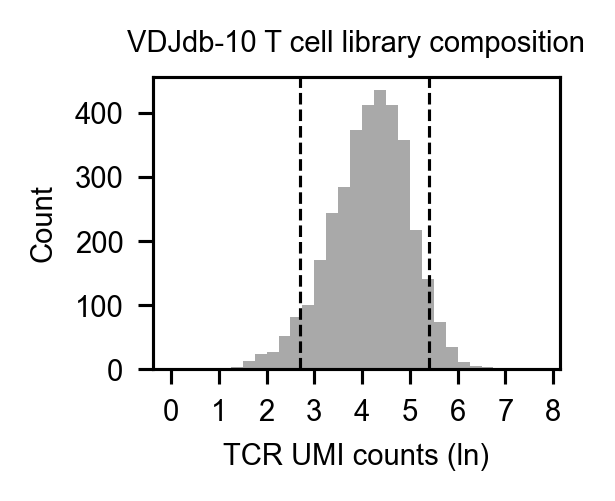

In [ ]:
ax, fig, gs = startfig(5.25, 4.5)

print(
    merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ]
    .mean(1)
    .max()
)
ax.hist(
    merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ].mean(1),
    bins=np.arange(0, 8, 0.25),
    color="darkgrey",
)

print(
    merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ]
    .mean(1)
    .quantile(0.95)
    / merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ]
    .mean(1)
    .quantile(0.05)
)
print(
    merged_count_df.loc[:, ["Count_a", "Count_b", "Count_c"]].mean(1).quantile(0.95)
    / merged_count_df.loc[:, ["Count_a", "Count_b", "Count_c"]].mean(1).quantile(0.05)
)

ax.axvline(
    merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ]
    .mean(1)
    .quantile(0.05),
    linewidth=0.75,
    color="black",
    linestyle="--",
)
ax.axvline(
    merged_count_df.loc[
        :,
        [
            "log_transformed_count_a",
            "log_transformed_count_b",
            "log_transformed_count_c",
        ],
    ]
    .mean(1)
    .quantile(0.95),
    linewidth=0.75,
    color="black",
    linestyle="--",
)

ax.set_xticks(np.arange(0, 9, 1))
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax.set_ylabel("Count", fontsize=7)
ax.set_title("VDJdb-10 T cell library composition", fontsize=7)
fig.tight_layout()
fig.savefig(
    "stapler_vdjdb_muTRBC_baseline_sort_umi_counts.pdf"
)

## Reading in DEseq2 validating, non-validating, ambiguous TCR calls

In [ ]:
with open(
    "experiment_set_stats_all-v-1.json"
) as json_in:
    screen_deseq2_dict = json.load(json_in)

rows = []
for epitope, values in screen_deseq2_dict.items():
    for key, tcr_list in values.items():
        if isinstance(tcr_list, list):
            for tcr in tcr_list:
                rows.append({"name": tcr, "epitope_aa": epitope, "reactive": key})

deseq2_res_df = pd.DataFrame(rows)
deseq2_res_df = deseq2_res_df.loc[deseq2_res_df.loc[:, "reactive"] != "all_ids", :]

In [4]:
print(deseq2_res_df.loc[:, "reactive"].value_counts())
print(deseq2_res_df.loc[:, "reactive"].value_counts().sum())

reactive
pos_ids                                               1321
neg_ids                                               1053
not_annotated_for_this_epitope_but_above_threshold     701
ambiguous_ids                                          219
intersection_ids                                        74
Name: count, dtype: int64
3368


In [5]:
deseq2_res_df.loc[deseq2_res_df["reactive"] == "pos_ids", "name"].value_counts()

name
1_1_H24_191_GILGFVFTL     1
1_8_H7_90_TTDPSFLGRY      1
1_5_E15_146_YLQPRTFLL     1
1_6_G13_168_YLQPRTFLL     1
1_5_C2_25_YLQPRTFLL       1
                         ..
2_14_C14_121_LLWNGPMAV    1
2_14_G17_172_LLWNGPMAV    1
2_14_B13_108_LLWNGPMAV    1
2_15_B11_22_LLWNGPMAV     1
2_13_G6_77_CINGVCWTV      1
Name: count, Length: 1321, dtype: int64

In [6]:
deseq2_res_df.loc[:, "epitope_aa"].unique().shape[0]
print(1321 + 1053 + 219 + 74 + 701)

3368


In [7]:
# 2993 unique TCRs names because ATD and SPR where removed from Bjørn's analysis
# deseq2_res_df has shape 3368 because there are duplicate TCR names between categories
deseq2_res_df.loc[:, "name"].value_counts()

name
2_17_D9_44_LTDEMIAQY      3
1_6_C3_26_YLQPRTFLL       3
1_4_G16_171_YLQPRTFLL     3
1_9_F24_167_NLVPMVATV     3
1_7_B8_19_TTDPSFLGRY      2
                         ..
2_17_A2_1_LTDEMIAQY       1
2_17_A5_4_LTDEMIAQY       1
2_16_F18_161_LTDEMIAQY    1
2_17_D1_36_LTDEMIAQY      1
2_11_F13_156_SPRWYFYYL    1
Name: count, Length: 2993, dtype: int64

In [8]:
sum(["SPR" in name for name in deseq2_res_df.loc[:, "name"]])

89

In [9]:
# All SPR TCR names are in not_annotated_for_this_epitope_but_above_threshold
deseq2_res_df.loc[
    deseq2_res_df["reactive"] == "not_annotated_for_this_epitope_but_above_threshold",
    "name",
].str.split("_").str[-1].value_counts()

name
SPRWYFYYL     89
NLVPMVATV     82
GILGFVFTL     79
YLQPRTFLL     76
TTDPSFLGRY    56
              ..
AVGVGKSAL      1
YTDFSSEII      1
KLLKSIAAT      1
VINGDRWFL      1
DYTEISFML      1
Name: count, Length: 175, dtype: int64

In [10]:
deseq2_summary_df = (
    deseq2_res_df.groupby("epitope_aa")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: (x.eq("pos_ids").sum()) / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: (x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()),
        ),
        number_of_tcrs_with_ambiguous=(
            "reactive",
            lambda x: (x.eq("pos_ids").sum())
            + (x.eq("neg_ids").sum())
            + (x.eq("ambiguous_ids").sum() + x.eq("intersection_ids").sum()),  # intersection_ids belongs to ambiguous
        ),
        ambiguous=("reactive", lambda x: (x.eq("ambiguous_ids").sum()) + (x.eq("intersection_ids").sum())),
        pos_ids=("reactive", lambda x: (x.eq("pos_ids").sum())),
        # intersection_pos_neg=("reactive", lambda x: (x.eq("intersection_ids").sum())),
        not_annotated_for_this_epi_but_above_threshold=(
            "reactive",
            lambda x: (x.eq("not_annotated_for_this_epitope_but_above_threshold").sum()),
        ),
    )
    .reset_index()
)

In [11]:
deseq2_summary_df

,epitope_aa,Fraction_validating,number_of_tcrs,number_of_tcrs_with_ambiguous,ambiguous,pos_ids,not_annotated_for_this_epi_but_above_threshold
0,CINGVCWTV,0.763158,228,243,15,174,92
1,GILGFVFTL,0.656897,580,675,95,381,87
2,GLCTLVAML,0.650888,169,195,26,110,78
3,LLWNGPMAV,0.753488,215,232,17,162,101
4,LTDEMIAQY,0.590551,127,132,5,75,85
5,NLVPMVATV,0.282609,322,371,49,91,86
6,TTDPSFLGRY,0.494186,344,389,45,170,84
7,YLQPRTFLL,0.406170,389,430,41,158,88


In [12]:
deseq2_summary_df.loc[:, "number_of_tcrs_with_ambiguous"].sum()

np.int64(2667)

In [13]:
deseq2_summary_df.loc[
    deseq2_summary_df["epitope_aa"].isin(["GLCTLVAML", "YLQPRTFLL"]), "number_of_tcrs_with_ambiguous"
].sum()

np.int64(625)

In [14]:
np.average(deseq2_summary_df["Fraction_validating"], weights=deseq2_summary_df["number_of_tcrs"])

np.float64(0.5564448188711036)

## Figure S3B

6.953148392719538
2.0049932761809246


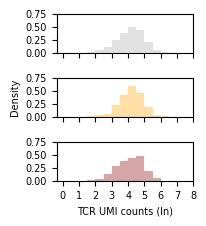

In [ ]:
fig, gs = startfig(5.5, 6, rows=3, columns=1, return_first_ax=False)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)

bins = np.arange(0, 8, 0.5)

values_all = merged_count_df.loc[
    :, ["log_transformed_count_a", "log_transformed_count_b", "log_transformed_count_c"]
].mean(1)

values_pos = merged_count_df.loc[
    merged_count_df.loc[:, "TCR"].isin(deseq2_res_df.loc[deseq2_res_df.loc[:, "reactive"] == "pos_ids", "name"].values),
    ["log_transformed_count_a", "log_transformed_count_b", "log_transformed_count_c"],
].mean(1)

values_neg = merged_count_df.loc[
    merged_count_df.loc[:, "TCR"].isin(deseq2_res_df.loc[deseq2_res_df.loc[:, "reactive"] == "neg_ids", "name"].values),
    ["log_transformed_count_a", "log_transformed_count_b", "log_transformed_count_c"],
].mean(1)

print(values_all.max())
ax1.hist(values_all, bins=bins, color="darkgrey", density=True, alpha=0.35)
ax1.tick_params(labelbottom=False)
ax1.tick_params("both", labelsize=7)
ax1.set_yticks([0, 0.25, 0.5, 0.75])
ax1.set_ylim(0, 0.75)


ax2.hist(values_pos, bins=bins, color="orange", density=True, alpha=0.35)
ax2.tick_params(labelbottom=False)
ax2.set_ylabel("Density", fontsize=7)
ax2.tick_params("both", labelsize=7)
ax2.set_yticks([0, 0.25, 0.5, 0.75])
ax2.set_ylim(0, 0.75)


ax3.hist(values_neg, bins=bins, color="darkred", density=True, alpha=0.35)
ax3.set_xlabel("TCR UMI counts (ln)", fontsize=7)
ax3.set_xticks(np.arange(0, 9, 1))
ax3.tick_params(axis="both", labelsize=7)
ax3.set_yticks([0, 0.25, 0.5, 0.75])
ax3.set_ylim(0, 0.75)

print(values_all.quantile(0.95) / values_all.quantile(0.05))

fig.tight_layout()

fig.savefig(
    "stapler_vdjdb_muTRBC_baseline_sort_umi_counts_colored_by_validating.pdf"
)

## Figures 3A, 3B, 3C
Associating VDJDb TCR annotation columns with validating, non-validating, ambiguous result

In [ ]:
drop_cols = ["cdr3fix.alpha", "cdr3fix.beta"]
vdjdb_df = pd.read_csv(
    "vdjdb_full.txt",
    sep="\t",
    header=0,
    low_memory=False,
)
vdjdb_df.drop(drop_cols, axis=1, inplace=True)
vdjdb_df = vdjdb_df.loc[
    vdjdb_df.loc[:, "reference.id"]
    != "https://www.10xgenomics.com/resources/application-notes/a-new-way-of-exploring-immunity-linking-highly-multiplexed-antigen-recognition-to-immune-repertoire-and-phenotype/#",
    :,
].copy()
vdjdb_df.dropna(
    subset=["cdr3.alpha", "v.alpha", "j.alpha", "cdr3.beta", "v.beta", "j.beta"],
    axis=0,
    inplace=True,
)
vdjdb_df = vdjdb_df.loc[
    (vdjdb_df.loc[:, "mhc.class"] == "MHCI") & (vdjdb_df.loc[:, "species"] == "HomoSapiens"),
    :,
].copy()
reference_id_map = {
    "https://github.com/antigenomics/vdjdb-db/issues/326": "PMID:35383307",
    "https://doi.org/10.1016/j.xcrm.2023.101017": "PMID:37030296",
}

vdjdb_df.loc[:, "reference.id"] = vdjdb_df.loc[:, "reference.id"].map(reference_id_map).fillna(vdjdb_df["reference.id"])
print(vdjdb_df.shape[0])

7132


In [16]:
vdjdb_df.loc[:, "antigen.epitope"].value_counts()[:40]

antigen.epitope
GILGFVFTL       841
NLVPMVATV       578
YLQPRTFLL       472
SPRWYFYYL       427
TTDPSFLGRY      399
GLCTLVAML       255
LLWNGPMAV       247
CINGVCWTV       245
LTDEMIAQY       135
ATDALMTGF       133
QYIKWPWYI       131
KTFPPTEPK       126
KSKRTPMGF       126
DATYQRTRALVR    109
NQKLIANQF        77
ELAGIGILTV       71
MEVTPSGTWL       69
RAQAPPPSW        69
HPVTKYIM         65
TPRVTGGGAM       62
NYNYLYRLF        56
GPRLGVRAT        52
RLPGVLPRA        43
FTSDYYQLY        42
PTDNYITTY        37
KLVALGINAV       35
LLYDANYFL        34
RPPIFIRRL        33
RPRGEVRFL        30
VYFLQSINF        29
RPHERNGFTVL      28
ALWEIQQVV        27
ALSKGVHFV        24
LPRWYFYYL        24
RVAGDSGFAAY      24
RLGPVQNEV        23
KLSALGINAV       22
YSEHPTFTSQY      22
KLWAQCVQL        21
TAFTIPSI         19
Name: count, dtype: int64

In [17]:
top_epitope_list = [
    "GILGFVFTL",
    "YLQPRTFLL",
    "TTDPSFLGRY",
    "NLVPMVATV",
    "CINGVCWTV",
    "LLWNGPMAV",
    "GLCTLVAML",
    "LTDEMIAQY",
]
vdjdb_df = vdjdb_df.loc[vdjdb_df.loc[:, "antigen.epitope"].isin(top_epitope_list), :].copy()

In [18]:
vdjdb_df.loc[:, "method.identification"].value_counts(normalize=True)

method.identification
tetramer-sort                                              0.562104
dextramer-sort                                             0.302915
dextramer-sort,beads                                       0.062421
tetramer-sort,beads                                        0.027567
antigen-loaded-targets,dextramer-sort                      0.012357
monomer-sort                                               0.010139
limiting-dilution-cloning                                  0.006337
antigen-loaded-target,limiting-dilution-cloning            0.005387
pelimer-sort                                               0.004436
limiting-dilution-cloning,tetramer-sort                    0.001584
tetramer-sort,antigen-expressing cells,cultured-T-cells    0.001584
cultured-T-cells,antigen-expressing-targets                0.001267
tetramer-sort,limiting-dilution-cloning                    0.000634
antigen-loaded-targets                                     0.000634
cultured-T-cells,dextramer

In [19]:
(0.562104 + 0.302915 + 0.062421 + 0.027567 + 0.012357 + 0.010139 + 0.004436 + 0.001584 + 0.001584 + 0.000634 + 0.000317)

0.986058

In [20]:
vdjdb_df.loc[vdjdb_df.loc[:, "vdjdb.score"] == 3, "meta.structure.id"].value_counts()

meta.structure.id
5EUO    1
56I     1
7n6e    1
7n1f    1
5tez    1
5jhd    1
5isz    1
5euo    1
5e6i    1
5d2n    1
5d2l    1
3o4l    1
3gsn    1
2vlr    1
2vlk    1
2vlj    1
1oga    1
7rtr    1
Name: count, dtype: int64

In [21]:
vdjdb_df.loc[:, "vdjdb.score"].value_counts(normalize=True) * 100

vdjdb.score
0    73.013871
1    13.587642
3    11.633039
2     1.765448
Name: proportion, dtype: float64

In [22]:
epitope_ranked_list = vdjdb_df.loc[:, "antigen.epitope"].value_counts(normalize=True).index.tolist()
print(epitope_ranked_list)

['GILGFVFTL', 'NLVPMVATV', 'YLQPRTFLL', 'TTDPSFLGRY', 'GLCTLVAML', 'LLWNGPMAV', 'CINGVCWTV', 'LTDEMIAQY']


In [23]:
vdjdb_df.shape[0]

3172

In [24]:
vdjdb_df.loc[:, "clonotype_aa"] = (
    vdjdb_df.loc[:, "v.alpha"].str.split("*").str[0]
    + "_"
    + vdjdb_df.loc[:, "cdr3.alpha"].str.split("*").str[0]
    + "_"
    + vdjdb_df.loc[:, "j.alpha"].str.split("*").str[0]
    + "--"
    + vdjdb_df.loc[:, "v.beta"].str.split("*").str[0]
    + "_"
    + vdjdb_df.loc[:, "cdr3.beta"].str.split("*").str[0]
    + "_"
    + vdjdb_df.loc[:, "j.beta"].str.split("*").str[0]
)

In [ ]:
tcr_refs_df = pd.read_csv(
    "/tcr_toolbox_tcr_assembly_runs/r3_2023-08-23_any_mers_full_seq_dataset_vdjdb_only/v6/sequencing_quality_analysis/references/tcr_refs_df.csv"
)

In [26]:
tcr_refs_df.loc[:, "clonotype_aa"] = (
    tcr_refs_df.loc[:, "TRAV"].str.split("*").str[0]
    + "_"
    + tcr_refs_df.loc[:, "cdr3_alpha_aa"].str.split("*").str[0]
    + "_"
    + tcr_refs_df.loc[:, "TRAJ"].str.split("*").str[0]
    + "--"
    + tcr_refs_df.loc[:, "TRBV"].str.split("*").str[0]
    + "_"
    + tcr_refs_df.loc[:, "cdr3_beta_aa"].str.split("*").str[0]
    + "_"
    + tcr_refs_df.loc[:, "TRBJ"].str.split("*").str[0]
)

In [27]:
print(deseq2_res_df.shape[0])
col_select_list = [
    "clonotype_aa",
    "name",
    "cdr3_alpha_aa",
    "cdr3_beta_aa",
    "TRAV_IMGT",
    "TRAJ_IMGT",
    "TRBV_IMGT",
    "TRBJ_IMGT",
]
deseq2_res_df = pd.merge(deseq2_res_df, tcr_refs_df.loc[:, col_select_list], on="name")
print(deseq2_res_df.shape[0])

3368
3368


In [28]:
deseq2_res_df.loc[:, "reactive"].value_counts()

reactive
pos_ids                                               1321
neg_ids                                               1053
not_annotated_for_this_epitope_but_above_threshold     701
ambiguous_ids                                          219
intersection_ids                                        74
Name: count, dtype: int64

In [29]:
print(deseq2_res_df.shape[0], vdjdb_df.shape[0])
vdjdb_df = vdjdb_df.loc[
    :,
    [
        "meta.structure.id",
        "vdjdb.score",
        "mhc.a",
        "meta.study.id",
        "method.identification",
        "method.sequencing",
        "method.singlecell",
        "meta.subject.cohort",
        "reference.id",
        "method.verification",
        "antigen.gene",
        "clonotype_aa",
    ],
].copy()
vdjdb_deseq2_df = pd.merge(vdjdb_df, deseq2_res_df, on="clonotype_aa", how="inner")
print(vdjdb_deseq2_df.shape[0])

3368 3172
3437


In [30]:
print(vdjdb_deseq2_df.shape[0])
vdjdb_deseq2_df.drop_duplicates(
    [
        "reactive",
        "clonotype_aa",
        "name",
        "method.identification",
        "reference.id",
        "method.verification",
        "method.sequencing",
        "method.singlecell",
        "vdjdb.score",
    ],
    inplace=True,
)
print(vdjdb_deseq2_df.shape[0])

3437
3311


In [31]:
vdjdb_deseq2_df.loc[vdjdb_deseq2_df.loc[:, "name"] == "1_6_G13_168_YLQPRTFLL", "meta.structure.id"]


2923     NaN
2968    7n6e
Name: meta.structure.id, dtype: object

In [32]:
vdjdb_deseq2_df.loc[:, "name"].value_counts()

name
1_3_B23_118_GILGFVFTL     7
1_4_A10_9_GILGFVFTL       7
1_3_F1_60_GILGFVFTL       6
1_4_C9_32_GILGFVFTL       6
2_16_G10_81_GLCTLVAML     5
                         ..
1_5_G2_73_YLQPRTFLL       1
1_7_E11_58_TTDPSFLGRY     1
2_16_C21_128_LTDEMIAQY    1
1_7_F9_68_TTDPSFLGRY      1
1_5_C21_128_YLQPRTFLL     1
Name: count, Length: 2667, dtype: int64

In [33]:
# Duplicates should stay because they are from different studies:
vdjdb_deseq2_df.loc[vdjdb_deseq2_df.loc[:, "name"] == "1_3_B23_118_GILGFVFTL", "reference.id"]

127     PMID:29483513
164     PMID:29483513
205     PMID:28423320
894     PMID:29997621
1778    PMID:28636592
2954    PMID:12796775
2955    PMID:18275829
Name: reference.id, dtype: object

In [34]:
vdjdb_deseq2_df.loc[:, "clonotype_aa"].unique().shape[0]

2667

In [35]:
frac_val_method_df = (
    vdjdb_deseq2_df.groupby("method.identification")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)

frac_val_sequencing_df = (
    vdjdb_deseq2_df.groupby("method.sequencing")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)

frac_val_epi_df = (
    vdjdb_deseq2_df.groupby("epitope_aa")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)

frac_val_verification_df = (
    vdjdb_deseq2_df.groupby("method.verification")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)

frac_val_donor_df = (
    vdjdb_deseq2_df.groupby("meta.subject.cohort")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)


frac_val_pmid_df = (
    vdjdb_deseq2_df.groupby("reference.id")
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
    )
    .reset_index()
)


frac_val_epitope_pmid_df = (
    vdjdb_deseq2_df.groupby(["epitope_aa", "reference.id"])
    .agg(
        Fraction_validating=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
        ),
        number_val_tcrs=("reactive", lambda x: x.eq("pos_ids").sum()),
        number_non_val_tcrs=("reactive", lambda x: x.eq("neg_ids").sum()),
    )
    .reset_index()
)

frac_val_epitope_ambig_pmid_df = (
    vdjdb_deseq2_df.groupby(["epitope_aa", "reference.id"])
    .agg(
        Fraction_ambiguous=(
            "reactive",
            lambda x: x.eq("ambiguous_ids").sum()
            / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum() + x.eq("ambiguous_ids").sum()))
            if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum() + x.eq("ambiguous_ids").sum()) > 0
            else float("nan"),
        ),
        number_of_tcrs=(
            "reactive",
            lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum() + x.eq("ambiguous_ids").sum(),
        ),
    )
    .reset_index()
)


In [36]:
frac_val_pmid_df = (
    frac_val_pmid_df.loc[frac_val_pmid_df.loc[:, "number_of_tcrs"] > 5, :]
    .sort_values("Fraction_validating", ascending=False)
    .copy()
)

study_number_map = dict(
    zip(
        frac_val_pmid_df.loc[:, "reference.id"].unique(),
        ["Study " + str(number) for number in np.arange(1, len(frac_val_pmid_df.loc[:, "reference.id"].unique()) + 1)],
    )
)
# pmid_color_map = generate_color_dict(frac_val_pmid_df.loc[:, "reference.id"].unique())

In [44]:
study_number_map

{'PMID:28623251': 'Study 1',
 'PMID:29483513': 'Study 2',
 'PMID:26860370': 'Study 3',
 'PMID:28423320': 'Study 4',
 'PMID:27645996': 'Study 5',
 'PMID:28103239': 'Study 6',
 'PMID:34793243': 'Study 7',
 'PMID:36711524': 'Study 8',
 'PMID:33664060': 'Study 9',
 'PMID:28636592': 'Study 10',
 'PMID:28934479': 'Study 11',
 'PMID:33951417': 'Study 12',
 'https://github.com/antigenomics/vdjdb-db/issues/252': 'Study 13',
 'PMID:29997621': 'Study 14',
 'PMID:35383307': 'Study 15',
 'PMID:28636589': 'Study 16',
 'PMID:35750048': 'Study 17',
 'PMID:37030296': 'Study 18',
 'PMID:11046006': 'Study 19',
 'https://doi.org/10.1101/2020.05.04.20085779': 'Study 20',
 'PMID:16237109': 'Study 21'}

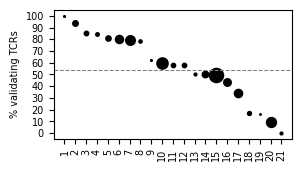

In [ ]:
ax, fig, gs = startfig(0.33 * frac_val_pmid_df.shape[0] + 1, 4.6)
for i, (frac_val, number_of_tcrs, study) in enumerate(
    zip(
        frac_val_pmid_df.loc[:, "Fraction_validating"],
        frac_val_pmid_df.loc[:, "number_of_tcrs"],
        frac_val_pmid_df.loc[:, "reference.id"],
    )
):
    ax.scatter(i, frac_val * 100, color="black", s=number_of_tcrs / 5)

ax.axhline(
    np.average(
        frac_val_pmid_df.loc[:, "Fraction_validating"],
        weights=frac_val_pmid_df.loc[:, "number_of_tcrs"],
    )
    * 100,
    color="grey",
    linestyle="--",
    linewidth=0.75,
)

ax.set_ylim(-5, 105)
ax.set_xlim(-1, i + 1)
# ax.set_title("All TCRs (n = )", fontsize=7)
ax.set_ylabel("% validating TCRs", fontsize=7)
ax.set_yticks(np.arange(0, 110, 10))
ax.set_xticks(np.arange(0, i + 1))
ax.set_xticklabels(
    [study_number_map[study].split(" ")[1] for study in frac_val_pmid_df.loc[:, "reference.id"]],
    fontsize=7,
    rotation=90,
)
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
fig.savefig(
    "fraction_validating_pmid_all_epitopes.pdf"
)


In [38]:
epitope_color_map = {
    "other": "lightgrey",
    "GILGFVFTL": "plum",  # red
    "YLQPRTFLL": "cornflowerblue",  # blue
    "TTDPSFLGRY": "forestgreen",  # green
    "NLVPMVATV": "darkorange",  # orange
    "SPRWYFYYL": "mediumorchid",  # purple
    "CINGVCWTV": "darkturquoise",  # turquoise
    "LLWNGPMAV": "gold",  # yellow
    "GLCTLVAML": "indianred",  # deep red
    "LTDEMIAQY": "darkviolet",  # violet
    "ATDALMTGF": "teal",
}  # teal

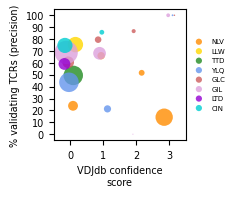

In [ ]:
min_number_list = []
max_number_list = []
ax, fig, gs = startfig(6.3, 5.275)
for epitope in vdjdb_deseq2_df.loc[:, "epitope_aa"].unique():
    full_scores_df = pd.DataFrame({"vdjdb.score": np.arange(0, 4)})

    frac_val_vdjdb_score_df = (
        vdjdb_deseq2_df.loc[vdjdb_deseq2_df.loc[:, "epitope_aa"] == epitope, :]
        .groupby("vdjdb.score")
        .agg(
            Fraction_validating=(
                "reactive",
                lambda x: x.eq("pos_ids").sum() / ((x.eq("pos_ids").sum()) + (x.eq("neg_ids").sum()))
                if (x.eq("pos_ids").sum() + x.eq("neg_ids").sum()) > 0
                else float("nan"),
            ),
            number_of_tcrs=(
                "reactive",
                lambda x: x.eq("pos_ids").sum() + x.eq("neg_ids").sum(),
            ),
        )
        .reset_index()
    )

    frac_val_vdjdb_score_df = full_scores_df.merge(frac_val_vdjdb_score_df, on="vdjdb.score", how="left")

    min_number_list.append(frac_val_vdjdb_score_df.loc[:, "number_of_tcrs"].min())
    max_number_list.append(frac_val_vdjdb_score_df.loc[:, "number_of_tcrs"].max())

    x = [x + np.random.uniform(-0.175, 0.175) for x in np.arange(0, 4)]
    ax.scatter(
        x,
        frac_val_vdjdb_score_df.loc[:, "Fraction_validating"] * 100,
        s=[number / 1.75 for number in frac_val_vdjdb_score_df.loc[:, "number_of_tcrs"]],
        color=epitope_color_map[epitope],
        alpha=0.8,
        edgecolors="none",
        label=epitope[:3],
    )

leg = ax.legend(fontsize=5, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

for lh in leg.legend_handles:
    lh.set_sizes([20])

ax.set_yticks(np.arange(0, 110, 10))
ax.set_ylim(-5, 105)
ax.set_xlim(-0.5, 3.5)
ax.set_xticks([0, 1, 2, 3])
ax.set_ylabel("% validating TCRs (precision)", fontsize=7)
ax.set_xlabel("VDJdb confidence\nscore", fontsize=7)
ax.tick_params(axis="both", labelsize=7)
fig.tight_layout()
fig.savefig(
    "percent_validating_vs_vdjdb_confidence_score_precision_per_epitope.pdf"
)

/var/folders/w6/4g13dtn528z_gtdhwddhyqz5hrjw4d/T/ipykernel_18007/461685466.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vdjdb_score_cum_sensitivity_last_df.sort_values("vdjdb.score", inplace = True)


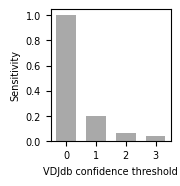

In [ ]:
vdjdb_deseq2_df_vdjdb_score_sorted = (
    vdjdb_deseq2_df.loc[:, ["vdjdb.score", "reactive"]].sort_values("vdjdb.score", ascending=False).copy()
)
vdjdb_deseq2_df_vdjdb_score_sorted.loc[:, "reactive_int"] = (
    vdjdb_deseq2_df_vdjdb_score_sorted["reactive"] == "pos_ids"
).astype(int)
vdjdb_deseq2_df_vdjdb_score_sorted.loc[:, "sensitivity"] = (
    vdjdb_deseq2_df_vdjdb_score_sorted.loc[:, "reactive_int"].cumsum()
    / vdjdb_deseq2_df_vdjdb_score_sorted.loc[:, "reactive_int"].sum()
)


vdjdb_score_cum_sensitivity_last_df = (
    vdjdb_deseq2_df_vdjdb_score_sorted.groupby("vdjdb.score", sort=False).tail(
        1
    )  # last row in each group after sorting
)

vdjdb_score_cum_sensitivity_last_df.sort_values("vdjdb.score", inplace=True)

bar_space = 0.35
bar_width = 0.7
num_bars = len(vdjdb_score_cum_sensitivity_last_df.loc[:, "vdjdb.score"].unique())

w = (num_bars * bar_width) + ((num_bars - 1) * bar_space) + 1
x_pos_list = np.arange(num_bars) * (bar_width + bar_space)
ax, fig, gs = startfig(w, 5)

ax.bar(
    x_pos_list,
    vdjdb_score_cum_sensitivity_last_df.loc[:, "sensitivity"],
    width=bar_width,
    color="darkgrey",
)
ax.set_xticks(x_pos_list)  # Set the positions of ticks
ax.set_xticklabels(vdjdb_score_cum_sensitivity_last_df.loc[:, "vdjdb.score"], fontsize=7)
ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([round(ytick, 1) for ytick in np.arange(0, 1.2, 0.2)])
ax.set_xlabel("VDJdb confidence threshold", fontsize=7)
ax.set_ylabel("Sensitivity", fontsize=7)
ax.tick_params(axis="both", labelsize=7)
# ax.set_title("All epitopes", fontsize=7)
fig.tight_layout()
fig.savefig(
    "percent_validating_vs_vdjdb_confidence_score_sensitivity.pdf"
)

## Figure S3J
VDJdb contributing studies were read and annotated based on their use of pre-expansion or no-pre-expansion in their methods

In [ ]:
original_df = pd.read_excel(
    "fraction_validating_epitope_pmid_annotation.xlsx",
    index_col=1,
)
original_df = original_df.loc[
    ~(original_df.loc[:, "confidence_in_percent_annotation"].isin(["low", "Low", "CAN'T FIND?"])), :
]

In [42]:
original_df_merge = pd.merge(
    original_df,
    frac_val_epitope_pmid_df.loc[:, ["epitope_aa", "Fraction_validating", "reference.id", "number_of_tcrs"]],
    on=["epitope_aa", "reference.id"],
    how="left",
)

original_df_merge.drop(["Fraction_validating_x", "number_of_tcrs_x"], axis = 1, inplace = True)
original_df_merge.rename({"Fraction_validating_y": "Fraction_validating", "number_of_tcrs_y": "number_of_tcrs"}, axis = 1, inplace = True)

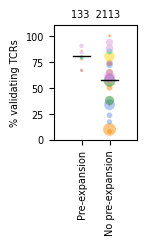

In [ ]:
ax, fig, gs = startfig(4, 6.5)
frac_val_exp_df = original_df_merge.loc[
    original_df_merge.loc[:, "percent_pre_expansion"] == 100, ["Fraction_validating", "number_of_tcrs", "epitope_aa"]
]
frac_val_no_exp_df = original_df_merge.loc[
    original_df_merge.loc[:, "percent_pre_expansion"] == 0, ["Fraction_validating", "number_of_tcrs", "epitope_aa"]
]

ax.scatter(
    [0.5] * frac_val_exp_df.shape[0] + [1] * frac_val_no_exp_df.shape[0],
    np.array(frac_val_exp_df["Fraction_validating"].to_list() + frac_val_no_exp_df["Fraction_validating"].to_list())
    * 100,
    s=np.array(frac_val_exp_df["number_of_tcrs"].to_list() + frac_val_no_exp_df["number_of_tcrs"].to_list()) / 3,
    color=[epitope_color_map[epitope] for epitope in list(frac_val_exp_df["epitope_aa"]) + list(frac_val_no_exp_df["epitope_aa"])],
    alpha=0.5,
    edgecolors="none",
)
ax.plot(
    [0.35, 0.65],
    [
        np.mean(frac_val_exp_df["Fraction_validating"].to_list()) * 100,
        np.mean(frac_val_exp_df["Fraction_validating"].to_list()) * 100,
    ],
    color="black",
    linewidth=1,
)
ax.plot(
    [0.85, 1.15],
    [
        np.mean(frac_val_no_exp_df["Fraction_validating"].to_list()) * 100,
        np.mean(frac_val_no_exp_df["Fraction_validating"].to_list()) * 100,
    ],
    color="black",
    linewidth=1,
)
ax.set_xlim(0, 1.5)
ax.set_xticks([0.5, 1])
ax.set_ylim(0, 110)
ax.set_ylabel("% validating TCRs", fontsize=7)
ax.set_xticklabels(["Pre-expansion", "No pre-expansion"], fontsize=7, rotation=90)
ax.tick_params("both", labelsize=7)
ax.set_title(
    str(frac_val_exp_df["number_of_tcrs"].sum()) + "  " + str(frac_val_no_exp_df["number_of_tcrs"].sum()), fontsize=7
)
fig.tight_layout()
fig.savefig(
    "percent_validating_pre_vs_no_pre_expansion.pdf"
)

In [44]:
from scipy.stats import mannwhitneyu

# run test
u_stat, p_val = mannwhitneyu(
    frac_val_exp_df["Fraction_validating"].to_list(),
    frac_val_no_exp_df["Fraction_validating"].to_list(),
    alternative="two-sided",
)

print("Mann Whitney U:", u_stat)
print("p value:", p_val)


Mann Whitney U: 130.0
p value: 0.031563942619828554


In [46]:
print(np.max(np.array(frac_val_exp_df["number_of_tcrs"].to_list() + frac_val_no_exp_df["number_of_tcrs"].to_list())))

256


## Figure S3E
As sanity check, double check individuall co-cultured TCR aa clonotypes with screen TCR clonotypes for annotating individually co-cultured TCRs with screening results. 

In [ ]:
def generate_regions_set_from_ref_fa(
    reference: Union[str, os.PathLike[str]],
    remove_negative_control_regions: bool = False,
    negative_control_regions_suffix_str_tuple: tuple = None,
):
    if remove_negative_control_regions:
        regions_set = set()
        with pysam.FastxFile(reference) as fasta_in:
            for entry in fasta_in:
                if entry.name.endswith(negative_control_regions_suffix_str_tuple):
                    continue
                regions_set.add(entry.name)

        return regions_set

    regions_set = set()
    with pysam.FastxFile(reference) as fasta_in:
        for entry in fasta_in:
            regions_set.add(entry.name)

    return regions_set

In [ ]:
ref_set = generate_regions_set_from_ref_fa(
    reference="/tcr_toolbox_tcr_assembly_runs/r3_2023-08-23_any_mers_full_seq_dataset_vdjdb_only/v6/sequencing_quality_analysis/references/stapler_tcr_assembly_nanopore.fa"
)

In [ ]:
len(ref_set)

3693

In [ ]:
tcr_refs_df = tcr_refs_df.loc[tcr_refs_df.loc[:, "name"].isin(ref_set), :].copy()

In [ ]:
glc_aurelie_tcr_df = pd.read_excel(
    "selected_rows_df_GLCTLVAML_order_fixed_reactivity_result_annotated.xlsx"
)
glc_aurelie_tcr_df = glc_aurelie_tcr_df.loc[glc_aurelie_tcr_df.loc[:, "Ambiguous"] == 0, :]

ylq_aurelie_tcr_df = pd.read_excel(
    "selected_rows_df_YLQPRTFLL_order_reactivity_result_annotated.xlsx"
)
ylq_aurelie_tcr_df = ylq_aurelie_tcr_df.loc[ylq_aurelie_tcr_df.loc[:, "Ambiguous"] == 0, :]

In [ ]:
glc_aurelie_tcr_df.loc[:, "clonotype_aa"] = (
    glc_aurelie_tcr_df.loc[:, "TRAV"].str.split("*").str[0]
    + "_"
    + glc_aurelie_tcr_df.loc[:, "cdr3_alpha_aa"].str.split("*").str[0]
    + "_"
    + glc_aurelie_tcr_df.loc[:, "TRAJ"].str.split("*").str[0]
    + "--"
    + glc_aurelie_tcr_df.loc[:, "TRBV"].str.split("*").str[0]
    + "_"
    + glc_aurelie_tcr_df.loc[:, "cdr3_beta_aa"].str.split("*").str[0]
    + "_"
    + glc_aurelie_tcr_df.loc[:, "TRBJ"].str.split("*").str[0]
)

ylq_aurelie_tcr_df.loc[:, "clonotype_aa"] = (
    ylq_aurelie_tcr_df.loc[:, "TRAV"].str.split("*").str[0]
    + "_"
    + ylq_aurelie_tcr_df.loc[:, "cdr3_alpha_aa"].str.split("*").str[0]
    + "_"
    + ylq_aurelie_tcr_df.loc[:, "TRAJ"].str.split("*").str[0]
    + "--"
    + ylq_aurelie_tcr_df.loc[:, "TRBV"].str.split("*").str[0]
    + "_"
    + ylq_aurelie_tcr_df.loc[:, "cdr3_beta_aa"].str.split("*").str[0]
    + "_"
    + ylq_aurelie_tcr_df.loc[:, "TRBJ"].str.split("*").str[0]
)

In [ ]:
glc_aurelie_tcr_refs_merge_df = pd.merge(glc_aurelie_tcr_df, tcr_refs_df, how="inner", on="clonotype_aa")
ylq_aurelie_tcr_refs_merge_df = pd.merge(ylq_aurelie_tcr_df, tcr_refs_df, how="inner", on="clonotype_aa")

In [ ]:
ylq_pilot_translation_df = ylq_aurelie_tcr_refs_merge_df.loc[:, ["well_x", "name", "Reactive"]].copy()
ylq_pilot_translation_df.rename({"well_x": "aurelie_well"}, axis=1, inplace=True)
glc_pilot_translation_df = glc_aurelie_tcr_refs_merge_df.loc[:, ["final_well_fixed", "name", "Reactive"]].copy()
glc_pilot_translation_df.rename({"final_well_fixed": "aurelie_well"}, axis=1, inplace=True)

In [ ]:
print(ylq_pilot_translation_df.shape[0])
print(glc_pilot_translation_df.shape[0])

49
41


In [ ]:
ylq_pilot_translation_df.to_excel(
    "ylq_pilot_result_screen_translation.xlsx",
    index=False,
)
glc_pilot_translation_df.to_excel(
    "glc_pilot_result_screen_translation.xlsx",
    index=False,
)

## Figure 5A and 5B illustrations (example illustration plots)

In [ ]:
fig5_illustration_dict = {
    "TCR1": [0.98, 0.86, 0.82, 0.60, 0.7, 0.8, 0.75, 0.65],
    "TCR2": [0.8, 0.15, 0.2, 0.09, 0.07, 0.01, 0.02, 0.05],
}
color_list = ["limegreen", "silver", "silver", "silver", "silver", "silver", "silver", "silver"]

In [ ]:
vec = np.zeros(8)
vec[0] = 1
for v in range(1, 8):
    vec[v] = -1 / 7
vec = vec / np.linalg.norm(vec)
closeness_all = np.array([0.82, 0.10, 0.15, 0.09, 0.07, 0.01, 0.02, 0.05]) @ vec
print(closeness_all)

vec = np.zeros(8)
vec[0] = 1
for v in range(1, 8):
    vec[v] = -1 / 7
vec = vec / np.linalg.norm(vec)
closeness_all = np.array([0.98, 0.86, 0.82, 0.60, 0.7, 0.8, 0.75, 0.65]) @ vec
print(closeness_all)

0.7015607600201139
0.22449944320643656


In [ ]:
vec = np.zeros(2)
vec[0] = 1
for v in range(1, 2):
    vec[v] = -1 / 2
vec = vec / np.linalg.norm(vec)
closeness_all = np.array([0.90, 0.15]) @ vec
print(closeness_all)

0.7379024325749306


In [ ]:
(0.10, 0.88) = -0.30
(0.18, 0.10) =  0.12
(0.80, 0.90) =  0.31
(0.90, 0.15) =  0.74

In [132]:
x = 0.31
x_min = -0.30
x_max = 0.74

L = 0
H = 1

norm = (x - x_min) / (x_max - x_min)
scaled = L + norm * (H - L)
print(scaled)

0.5865384615384615


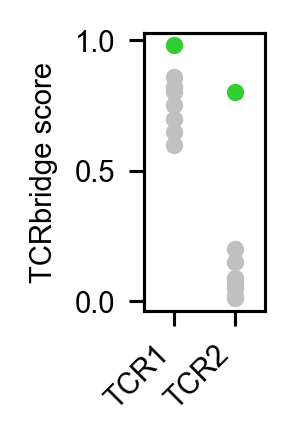

In [ ]:
ax, fig, gs = startfig(2.75, 4)

for tcr1, tcr2, color in zip(fig5_illustration_dict["TCR1"], fig5_illustration_dict["TCR2"], color_list):
    ax.scatter(x=[1, 2], y=[tcr1, tcr2], s=10, color=color)

# ax.plot([0.85, 1.15], [0.22, 0.22], color = "steelblue", linewidth = 1)
# ax.plot([1.85, 2.15], [0.72, 0.72], color = "steelblue", linewidth = 1)

# ax.plot([1, 2], [0.98, 0.85], color = "black", linewidth = 1, zorder = -4)
# ax.plot([1, 2], [0.225, 0.715], color = "steelblue", linewidth = 1)

# Add text right next to plot
# TCR1 has a higher absolute score than TCR1.
# TCR2 has a higher relative score (alignment score) than TCR1.
ax.set_xlim(0.5, 2.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["TCR1", "TCR2"], fontsize=7, rotation=45, ha="right")
ax.set_ylabel("TCRbridge score", fontsize=7)
ax.tick_params("both", labelsize=7)
fig.tight_layout()
fig.savefig(
    "absolute_vs_relative_alignment_score_illustration.pdf"
)

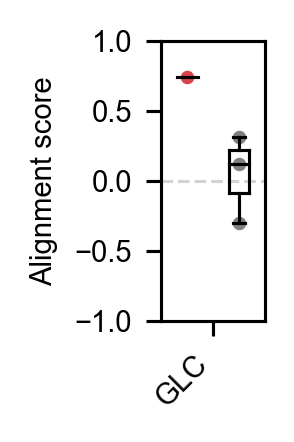

In [ ]:
ax, fig, gs = startfig(2.75, 4)

# for tcr1, tcr2, color in zip(fig5_illustration_dict["TCR1"], fig5_illustration_dict["TCR2"], color_list):

ax.scatter(x=[0.75], y=[0.74], s=5, color="#d94248")
ax.scatter(x=[1.25], y=[-0.30], s=5, color="grey")
ax.scatter(x=[1.25], y=[0.12], s=5, color="grey")
ax.scatter(x=[1.25], y=[0.31], s=5, color="grey")

ax.plot([0.65, 0.85], [0.74, 0.74], color="black", linewidth=0.75)

ax.plot([1.15, 1.35], [np.median([-0.30, 0.12, 0.31]), np.median([-0.30, 0.12, 0.31])], color="black", linewidth=0.75)

ax.plot(
    [1.15, 1.35],
    [np.quantile([-0.30, 0.12, 0.31], 0.25), np.quantile([-0.30, 0.12, 0.31], 0.25)],
    color="black",
    linewidth=0.75,
)

ax.plot(
    [1.15, 1.35],
    [np.quantile([-0.30, 0.12, 0.31], 0.75), np.quantile([-0.30, 0.12, 0.31], 0.75)],
    color="black",
    linewidth=0.75,
)


ax.plot(
    [1.15, 1.15],
    [np.quantile([-0.30, 0.12, 0.31], 0.25), np.quantile([-0.30, 0.12, 0.31], 0.75)],
    color="black",
    linewidth=0.75,
)

ax.plot(
    [1.35, 1.35],
    [np.quantile([-0.30, 0.12, 0.31], 0.25), np.quantile([-0.30, 0.12, 0.31], 0.75)],
    color="black",
    linewidth=0.75,
)

vals = np.array([-0.30, 0.12, 0.31])
q1 = np.quantile(vals, 0.25)
q3 = np.quantile(vals, 0.75)
iqr = q3 - q1

low = np.min(vals[vals >= q1 - 1.5 * iqr])
high = np.max(vals[vals <= q3 + 1.5 * iqr])

ax.plot([1.19, 1.31], [low, low], color="black", linewidth=0.75)

ax.plot([1.19, 1.31], [high, high], color="black", linewidth=0.75)


ax.plot([1.25, 1.25], [q3, high], color="black", linewidth=0.75)

ax.plot([1.25, 1.25], [q1, low], color="black", linewidth=0.75)


ax.axhline(0, color="lightgrey", linewidth=0.75, linestyle="--", zorder=-4)
ax.set_xlim(0.5, 1.5)
ax.set_ylim(-1, 1)
ax.set_xticks([1])
ax.set_xticklabels(["GLC"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Alignment score", fontsize=7)
ax.tick_params("both", labelsize=7)
fig.tight_layout()
fig.savefig(
    "alignmentscore_illustration_boxplot.pdf"
)